In [203]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [204]:
df=pd.read_csv("ccc.csv")

In [205]:
df

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114995,JOB012896,EmberReach Technologies,FAANG-tier,HealthTech,57977,UK,Software Engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-21,Filled,45.0,6.0,1.0,1.0,215300.0,254300.0,Yes
114996,JOB060961,AstraSuite,MNC,HealthTech,163658,Brazil,Data Scientist,Senior,4,10,...,NaN,NaN,Open,57.0,4.0,1.0,0.0,87500.0,113500.0,0
114997,JOB006013,MeridianLogix Co,Startup,Fintech,473,Canada,Analytics Engineer,Mid,2,6,...,2024-02-09 00:00:00,NaN,Cancelled,141.0,3.0,1.0,1.0,126000.0,156400.0,N
114998,JOB063108,WrenCampus,Mid-size,Cybersecurity,5425,India,Technical Program Manager,Senior,5,8,...,2024-09-04 00:00:00,NaN,Open,78.0,4.0,1.0,1.0,156000.0,174100.0,No


In [206]:
df.shape

(115000, 28)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [208]:
df.nunique()

job_id                          113000
company_name                       898
company_type                         5
sector                              24
company_size_employees           75225
hq_country                          13
job_role                           160
seniority_level                      6
years_experience_min                21
years_experience_max                21
required_tech_stack              29271
primary_programming_language        15
work_mode                           13
visa_sponsorship_offered             8
job_location_country                13
job_location_city                   41
salary_currency                     10
posting_date                      2638
application_deadline              2843
date_position_filled              2791
position_status                      4
number_of_applicants              1654
number_of_interview_rounds           8
offers_extended                      9
offers_accepted                     11
salary_min_usd           

In [209]:
df.duplicated().value_counts()

False    113807
True       1193
Name: count, dtype: int64

* the are 1193 duplicate rows which have to be removed

In [210]:
df=df.drop_duplicates()
print(df.duplicated().value_counts())
df=df.reset_index()


False    113807
Name: count, dtype: int64


- duplicates removed 

In [211]:
jobid=df['job_id']
print(jobid.isnull().value_counts())
print('-----------------------------')
print(jobid.duplicated().value_counts())

job_id
False    113807
Name: count, dtype: int64
-----------------------------
job_id
False    113000
True        807
Name: count, dtype: int64


In [212]:
samejobid=df[jobid.duplicated(keep=False)]
samejobid.sort_values('job_id')

,index,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
9277,9300,JOB000048,NovaFleet,FAANG-tier,E-commerce,161414,Canada,UI Designer,Lead,8,...,2022-05-02 00:00:00,2022-06-14,Filled,38.0,5.0,1.0,1.0,235600.0,291400.0,0
63769,64353,JOB000048,MeridianShield Labs,MNC,Social/AdTech,178480,India,Full Stack Engineer,Senior,5,...,2026-05-29 00:00:00,2026-06-12,Filled,93.0,3.0,1.0,1.0,139500.0,186300.0,No
48020,48411,JOB000066,PinnacleBlock Inc,MNC,Cloud/Infra,40537,UK,Mobile Engineer (Android),Senior,6,...,2022-11-12 00:00:00,2022-12-05,Filled,71.0,3.0,5.0,5.0,160000.0,202200.0,1
6420,6432,JOB000066,MeridianToken,MNC,EdTech,280690,USA,Frontend Engineer,Principal,12,...,2020-11-28 00:00:00,2021-01-11,Filled,14.0,5.0,1.0,1.0,301300.0,384700.0,False
40206,40517,JOB000165,OrbitNeural Technologies,FAANG-tier,E-commerce,151170,USA,Machine Learning Engineer,Mid,3,...,2025-11-03 00:00:00,NaN,Cancelled,172.0,3.0,0.0,0.0,163000.0,192900.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17015,17090,JOB111693,DriftDesk,Startup,SaaS,443,Germany,Product Manager,Mid,1,...,2022-02-19 00:00:00,NaN,Open,279.0,2.0,1.0,0.0,99200.0,127700.0,N
65345,65945,JOB111860,SpireCloud,MNC,Fintech,241384,USA,Machine Learning Engineer,Mid,3,...,2019-09-12 00:00:00,2019-09-21,Filled,99.0,4.0,1.0,1.0,97000.0,114200.0,0
387,387,JOB111860,BeaconPixel,MNC,Cloud/Infra,82059,Germany,UI Designer,Mid,3,...,2019-12-21 00:00:00,NaN,Cancelled,104.0,2.0,0.0,0.0,109900.0,133800.0,N
51282,51712,JOB112036,HalcyonCampus Technologies,Mid-size,Social/AdTech,1214,Germany,Backend Engineer,Senior,4,...,NaN,2025-02-28,Filled,52.0,5.0,1.0,1.0,Not Disclosed,Not Disclosed,N


In [213]:
samejobid['job_id'].value_counts().value_counts()

count
2    807
Name: count, dtype: int64

In [214]:
# same job id has occured maximum 2 times only

In [215]:
samejobid.groupby('job_id')['company_name'].nunique().value_counts()

company_name
2    794
1     13
Name: count, dtype: int64

13 x 2 = 26 companies have same name and job id

In [216]:
samejobid.groupby('job_id')['company_name'].nunique().sort_values().head(13)

job_id
JOB103181    1
JOB045762    1
JOB011486    1
JOB092024    1
JOB101144    1
JOB097118    1
JOB093066    1
JOB093157    1
JOB109622    1
JOB004304    1
JOB103221    1
JOB086302    1
JOB036114    1
Name: company_name, dtype: int64

In [217]:
same_id_name = df.duplicated(subset=['job_id', 'company_name'],keep=False)

In [218]:
df[same_id_name].sort_values('job_id')

,index,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
255,255,JOB004304,VertexBlock Inc,MNC,Gaming,102374,India,UX Researcher,Entry,0,...,2022-03-03 00:00:00,2022-02-04,Filled,143.0,2.0,1.0,1.0,61400.0,66500.0,0
18010,18097,JOB004304,VertexBlock Inc,MNC,Gaming,102374,India,UX Researcher,Entry,1,...,2022-03-03 00:00:00,2022-02-04,Filled,143.0,2.0,1.0,1.0,61400.0,66500.0,0
1942,1943,JOB011486,FusionTrade,MNC,Fintech,165215,UAE,Mobile Engineer (Android),Mid,7,...,2026-02-12 00:00:00,2026-03-12,Filled,91.0,2.0,1.0,1.0,Not Disclosed,Not Disclosed,False
92221,93154,JOB011486,FusionTrade,MNC,Fintech,165215,UAE,Mobile Engineer (Android),Mid,2,...,2026-02-12 00:00:00,2026-03-12,Filled,91.0,2.0,1.0,1.0,Not Disclosed,Not Disclosed,False
2968,2971,JOB036114,MeridianToken,MNC,EdTech,269078,USA,Full Stack Engineer,Intern,1,...,2026-08-05 00:00:00,2026-06-28,Filled,189.0,3.0,1.0,1.0,26800.0,31300.0,N
82900,83720,JOB036114,MeridianToken,MNC,EdTech,295893,USA,Product Manager,Principal,11,...,2022-06-04 00:00:00,2022-06-01,Filled,12.0,7.0,1.0,1.0,210800.0,248000.0,False
18386,18478,JOB045762,MeridianFleet Co,Mid-size,Logistics,3987,UK,Data Scientist,Mid,1,...,2020-10-05 00:00:00,2020-10-11,Filled,53.0,4.0,1.0,1.0,95700.0,105800.0,N
104570,105652,JOB045762,MeridianFleet Co,Mid-size,Logistics,4081,UK,Product Manager,Lead,7,...,2019-08-25 00:00:00,NaN,Open,18.0,4.0,1.0,1.0,158400.0,175800.0,No
80110,80898,JOB086302,SolaceShop Labs,Mid-size,EdTech,4795,India,DevOps Engineer,Mid,7,...,2021-06-25 00:00:00,2021-06-19,Filled,102.0,2.0,1.0,1.0,95200.0,106500.0,1
41137,41450,JOB086302,SolaceShop Labs,Mid-size,EdTech,4795,India,DevOps Engineer,Mid,1,...,2021-06-25 00:00:00,2021-06-19,Filled,102.0,2.0,1.0,1.0,95200.0,106500.0,1


In [219]:
df.describe()

,index,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,57427.326887,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,33221.286723,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,0.000000,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,28630.500000,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,57399.000000,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,86207.500000,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,114999.000000,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [220]:
df['years_experience_min'].isnull().value_counts()


years_experience_min
False    113807
Name: count, dtype: int64

## No null values in years_experience_min

In [221]:
df['years_experience_max'].isnull().value_counts()

years_experience_max
False    113807
Name: count, dtype: int64

### no null values in max experience age

In [222]:
experiencemin=df['years_experience_min']
print(experiencemin.describe())
experiencemin=experiencemin.value_counts()
experiencemin=experiencemin.sort_index(axis=0)


count    113807.000000
mean          3.004174
std           3.092817
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max          24.000000
Name: years_experience_min, dtype: float64


In [223]:
experiencemax=df['years_experience_max']
print(experiencemax.describe())
experiencemax=experiencemax.value_counts().sort_index(axis=0)

count    113807.000000
mean          6.664124
std           5.072197
min           0.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          24.000000
Name: years_experience_max, dtype: float64


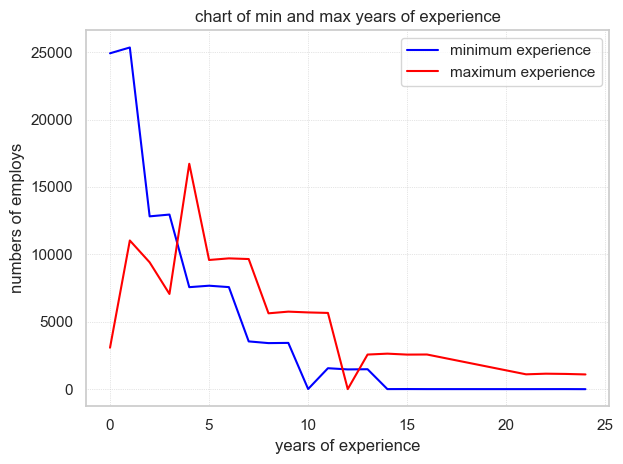

In [224]:
plt.plot(experiencemin,color="blue",label="minimum experience")
plt.plot(experiencemax,color="red",label='maximum experience')
plt.legend()
plt.title("chart of min and max years of experience")
plt.xlabel("years of experience")
plt.ylabel("numbers of employs")
plt.grid(axis='x',linewidth=0.5,linestyle='dotted')
plt.grid(axis='y',linewidth=0.5,linestyle='dotted')
plt.tight_layout()
plt.show()

* most of the people in the tech job market are new

In [225]:
df['salary_min_usd'].isnull().value_counts()

salary_min_usd
False    110527
True       3280
Name: count, dtype: int64

- some null values

In [226]:
df['salary_min_usd'].describe()

count     110527
unique      4795
top           -1
freq         727
Name: salary_min_usd, dtype: object

In [227]:
df["salary_min_usd"].dropna().sample(20, random_state=42)

87210      70200.0
3753       98500.0
17119     201300.0
107032    154400.0
283       154100.0
50433     127800.0
78840      54600.0
6878      184600.0
56515     205000.0
3342       96500.0
54803           -1
61194      86300.0
67803      65300.0
19556      14920.0
12643     171100.0
53582      87300.0
54797     116600.0
60796     124700.0
107277    147200.0
12692     114200.0
Name: salary_min_usd, dtype: object

In [228]:
df['salary_min_usd'].dtype

dtype('O')

In [229]:
df["salary_min_usd"] = df["salary_min_usd"].str.replace("$", "", regex=False)
df['salary_min_usd']=df['salary_min_usd'].str.replace("USD", "", regex=False)

In [230]:
df["salary_min_usd"] = pd.to_numeric(
    df["salary_min_usd"],
    errors="coerce"
)

In [231]:
df['salary_min_usd'].dtype

dtype('float64')

In [232]:
df['salary_min_usd'].describe()

count    108920.000000
mean     114665.400780
std       57608.647303
min          -1.000000
25%       75900.000000
50%      105400.000000
75%      145800.000000
max      531800.000000
Name: salary_min_usd, dtype: float64

In [233]:
(df["salary_min_usd"] == -1).sum()

np.int64(727)

In [234]:
df["salary_min_usd"] = df["salary_min_usd"].replace(-1, np.nan)

In [235]:
df['salary_min_usd'].describe()

count    108193.000000
mean     115435.898626
std       57027.292073
min        1700.000000
25%       76500.000000
50%      105900.000000
75%      146100.000000
max      531800.000000
Name: salary_min_usd, dtype: float64

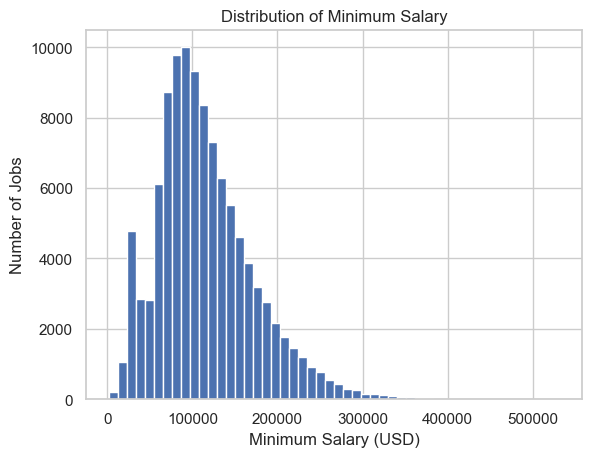

In [236]:
plt.hist(df["salary_min_usd"].dropna(), bins=50)
plt.xlabel("Minimum Salary (USD)")
plt.ylabel("Number of Jobs")
plt.title("Distribution of Minimum Salary")
plt.show()

- graph is right skewed

In [237]:
df["salary_min_usd"].isna().mean() * 100

np.float64(4.93291273823227)

- around 5 % of salary_min_usd is empty

In [238]:
df['salary_max_usd'].isnull().value_counts()

salary_max_usd
False    110527
True       3280
Name: count, dtype: int64

In [239]:
df["salary_max_usd"].dropna().sample(20, random_state=42)

87210      81200.0
3753      131100.0
17119     259000.0
107032    198700.0
283       167200.0
50433     145800.0
78840      60600.0
6878      235000.0
56515     251900.0
3342      105400.0
54803           -1
61194      99000.0
67803      77500.0
19556     164900.0
12643     216600.0
53582     117000.0
54797     149000.0
60796     144800.0
107277    170400.0
12692     139700.0
Name: salary_max_usd, dtype: object

In [240]:
df['salary_max_usd'].dtype

dtype('O')

In [241]:
df['salary_min_usd'].describe()

count    108193.000000
mean     115435.898626
std       57027.292073
min        1700.000000
25%       76500.000000
50%      105900.000000
75%      146100.000000
max      531800.000000
Name: salary_min_usd, dtype: float64

In [242]:
df['salary_max_usd'].value_counts()

salary_max_usd
-1               727
Not Disclosed    682
107000.0         102
104900.0         102
93400.0          102
                ... 
747000.0           1
838000.0           1
348100.0           1
360300.0           1
406800.0           1
Name: count, Length: 4157, dtype: int64

In [243]:
df["salary_max_usd"].dropna().sample(20, random_state=42)

87210      81200.0
3753      131100.0
17119     259000.0
107032    198700.0
283       167200.0
50433     145800.0
78840      60600.0
6878      235000.0
56515     251900.0
3342      105400.0
54803           -1
61194      99000.0
67803      77500.0
19556     164900.0
12643     216600.0
53582     117000.0
54797     149000.0
60796     144800.0
107277    170400.0
12692     139700.0
Name: salary_max_usd, dtype: object

In [244]:
df["salary_max_usd"] = pd.to_numeric(
    df["salary_max_usd"],
    errors="coerce"
)

In [245]:
df['salary_max_usd'].describe()

count    1.098450e+05
mean     1.417029e+05
std      9.163979e+04
min     -1.000000e+00
25%      9.190000e+04
50%      1.281000e+05
75%      1.774000e+05
max      3.552000e+06
Name: salary_max_usd, dtype: float64

In [246]:
df["salary_max_usd"] = df["salary_max_usd"].replace(-1, np.nan)

In [247]:
df["salary_max_usd"].isna().sum()

np.int64(4689)

In [248]:
df["salary_max_usd"].isna().mean() * 100

np.float64(4.120133207974905)

- around 4 % null values

In [249]:
(df["salary_min_usd"] > df["salary_max_usd"]).sum()

np.int64(443)

In [250]:
invalid_salary = df[df["salary_min_usd"] > df["salary_max_usd"]]
invalid_salary[["job_id","job_role","years_experience_min","years_experience_max","salary_min_usd","salary_max_usd"]].head(20)

,job_id,job_role,years_experience_min,years_experience_max,salary_min_usd,salary_max_usd
7,JOB057551,Embedded Systems Engineer,0,4,131100.0,103900.0
187,JOB080791,Cloud Engineer,5,11,153900.0,132400.0
335,JOB102070,SOC Analyst,6,10,182900.0,140800.0
702,JOB003325,Embedded Systems Engineer,3,7,71800.0,65300.0
1231,JOB040177,Security Engineer,6,9,208900.0,169200.0
1648,JOB074875,Backend Engineer,8,13,264100.0,220200.0
1787,JOB037816,Associate Product Manager,3,4,129900.0,107300.0
1808,JOB016573,Backend Engineer,0,2,33600.0,26300.0
1819,JOB072214,Mobile Engineer (Android),3,5,140500.0,115700.0
2090,JOB030952,Mobile Engineer (Android),1,6,169900.0,144800.0


- the minimum salaray is more than maximum salary

### interchanging minimum salary and maximum salary as they are reversed

In [251]:
reversing_index = df["salary_min_usd"] > df["salary_max_usd"]
df.loc[reversing_index, ["salary_min_usd", "salary_max_usd"]] = (df.loc[reversing_index, ["salary_max_usd", "salary_min_usd"]].values)

In [252]:
(df["salary_min_usd"] > df["salary_max_usd"]).sum()

np.int64(0)

In [253]:
df['salary_max_usd'].describe()

count    1.091180e+05
mean     1.427474e+05
std      9.122455e+04
min      1.590000e+04
25%      9.280000e+04
50%      1.288000e+05
75%      1.780000e+05
max      3.552000e+06
Name: salary_max_usd, dtype: float64

the max salary data is mathematically correct now

In [254]:
df.loc[df["salary_max_usd"].nlargest(20).index,["job_id", "job_role", "years_experience_min","years_experience_max", "salary_min_usd", "salary_max_usd"]
].sort_values("salary_max_usd", ascending=False)

,job_id,job_role,years_experience_min,years_experience_max,salary_min_usd,salary_max_usd
39257,JOB109116,Frontend Engineer,13,23,268300.0,3552000.0
93801,JOB018277,Cloud Engineer,5,9,284400.0,3460000.0
16043,JOB109246,Software Engineer,12,21,268700.0,3240000.0
22619,JOB041404,QA Engineer,13,22,271400.0,3148000.0
45002,JOB050680,Application Security Engineer,8,16,265400.0,3063000.0
36086,JOB012241,Infrastructure Engineer,5,10,231000.0,2986000.0
57179,JOB068419,Mobile Engineer (Android),11,23,263100.0,2981000.0
18576,JOB004739,Site Reliability Engineer,9,14,219800.0,2900000.0
75050,JOB001133,DevOps Engineer,9,14,235200.0,2870000.0
72962,JOB043205,Backend Engineer,9,15,220000.0,2856000.0


In [255]:
df['job_role'].value_counts()

job_role
Backend Engineer             5939
Embedded Systems Engineer    5912
QA Engineer                  5854
Software Engineer            5820
Frontend Engineer            5786
                             ... 
 QA Engineer                    1
 FRONTEND ENGINEER              1
 Data Analyst                   1
 Mobile Engineer (iOS)          1
 DATA ENGINEER                  1
Name: count, Length: 160, dtype: int64

In [256]:
df['job_role'].isnull().value_counts()

job_role
False    113807
Name: count, dtype: int64

- no job roll is null

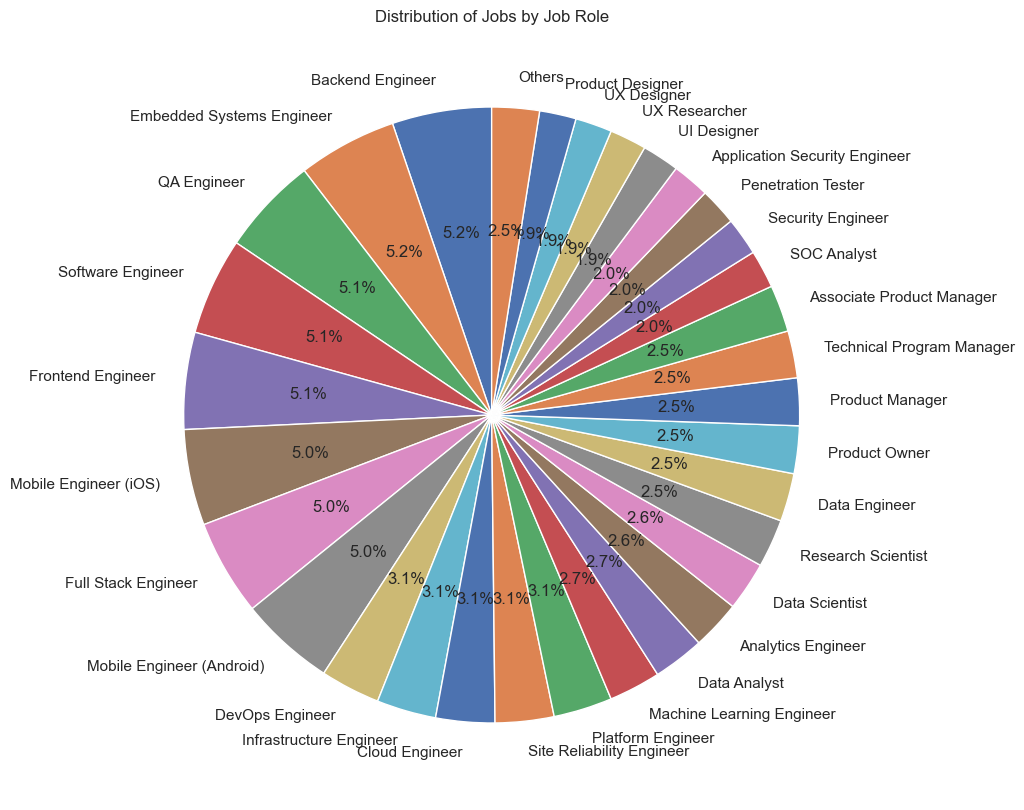

In [257]:
role_counts = df["job_role"].value_counts()
role_percent = role_counts / role_counts.sum() * 100
main_roles = role_counts[role_percent >= 1.9]
others = role_counts[role_percent < 1.9].sum()
pie_data = main_roles.copy()
pie_data["Others"] = others
plt.figure(figsize=(10, 10))
plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Jobs by Job Role")
plt.show()

In [258]:
program_lang=df['primary_programming_language']


In [259]:
program_lang.isnull().value_counts()

primary_programming_language
False    91544
True     22263
Name: count, dtype: int64

In [260]:
program_lang.value_counts()

primary_programming_language
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Unknown         548
TBD             530
Name: count, dtype: int64

In [261]:
df["primary_programming_language"] = df["primary_programming_language"].replace("TBD", np.nan)
df["primary_programming_language"] = df["primary_programming_language"].replace("Unknown", np.nan)

In [262]:
df['primary_programming_language'].value_counts()

primary_programming_language
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Name: count, dtype: int64

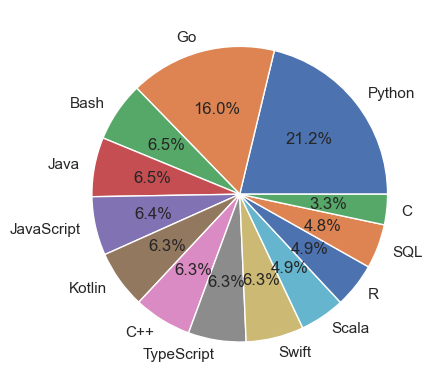

In [263]:
pdata=df['primary_programming_language'].value_counts()
plt.pie(pdata,labels=pdata.index,autopct="%1.1f%%")
plt.show()

- most of the programmer chose python as their primary language

- then GO

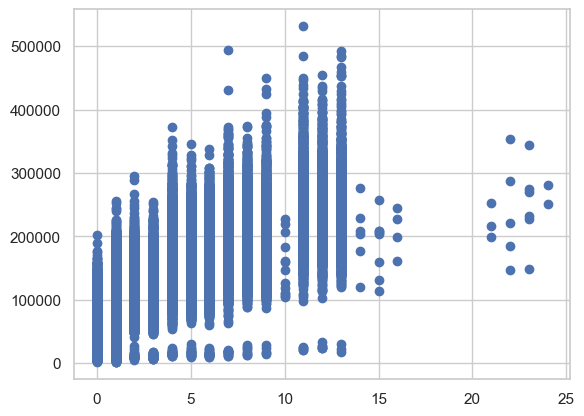

In [264]:
plt.scatter(df['years_experience_min'], df['salary_min_usd'])

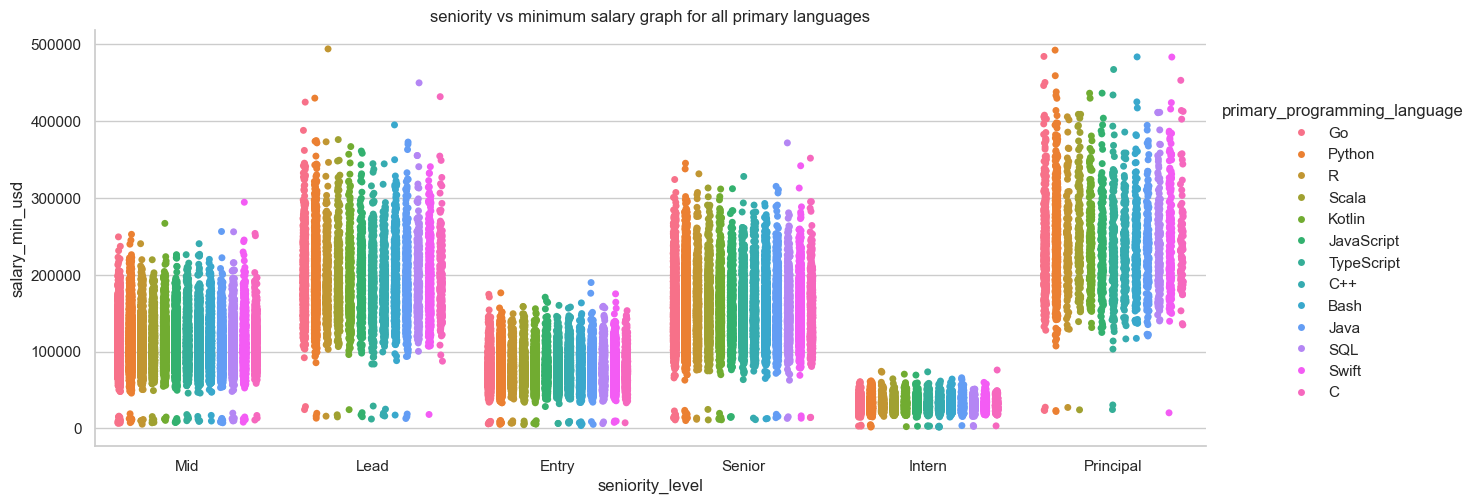

In [265]:

sns.catplot(data=df, x='seniority_level', y='salary_min_usd',hue="primary_programming_language",kind='strip',jitter=True,dodge=True,aspect=2.5)

plt.title("seniority vs minimum salary graph for all primary languages")

plt.show()

In [266]:
df['company_type'].value_counts()

company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

In [267]:
df['company_type'].isnull().value_counts()

company_type
False    113807
Name: count, dtype: int64

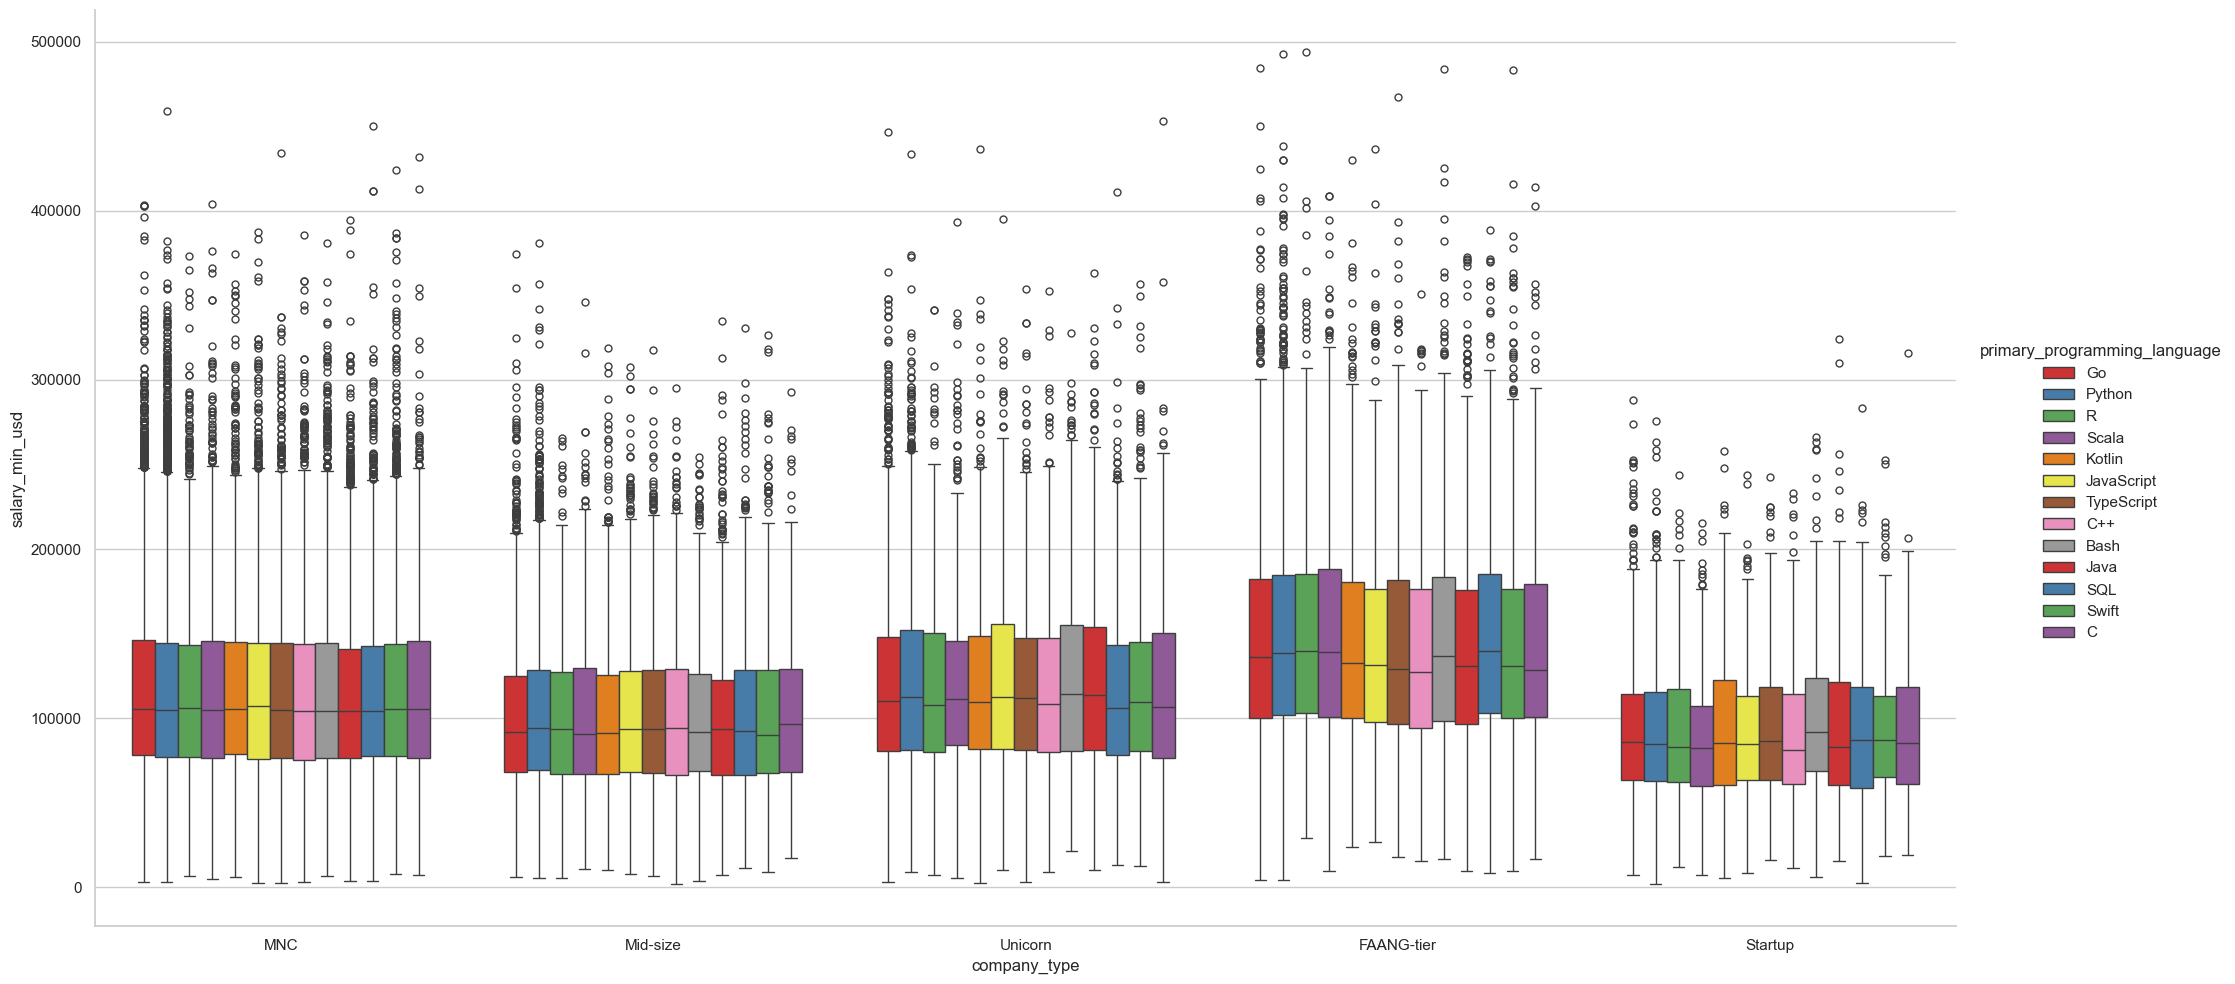

In [268]:
sns.catplot(data=df, x='company_type', y='salary_min_usd' ,hue='primary_programming_language', kind='box', dodge=True,height=10,aspect=2, palette='Set1')
plt.show()

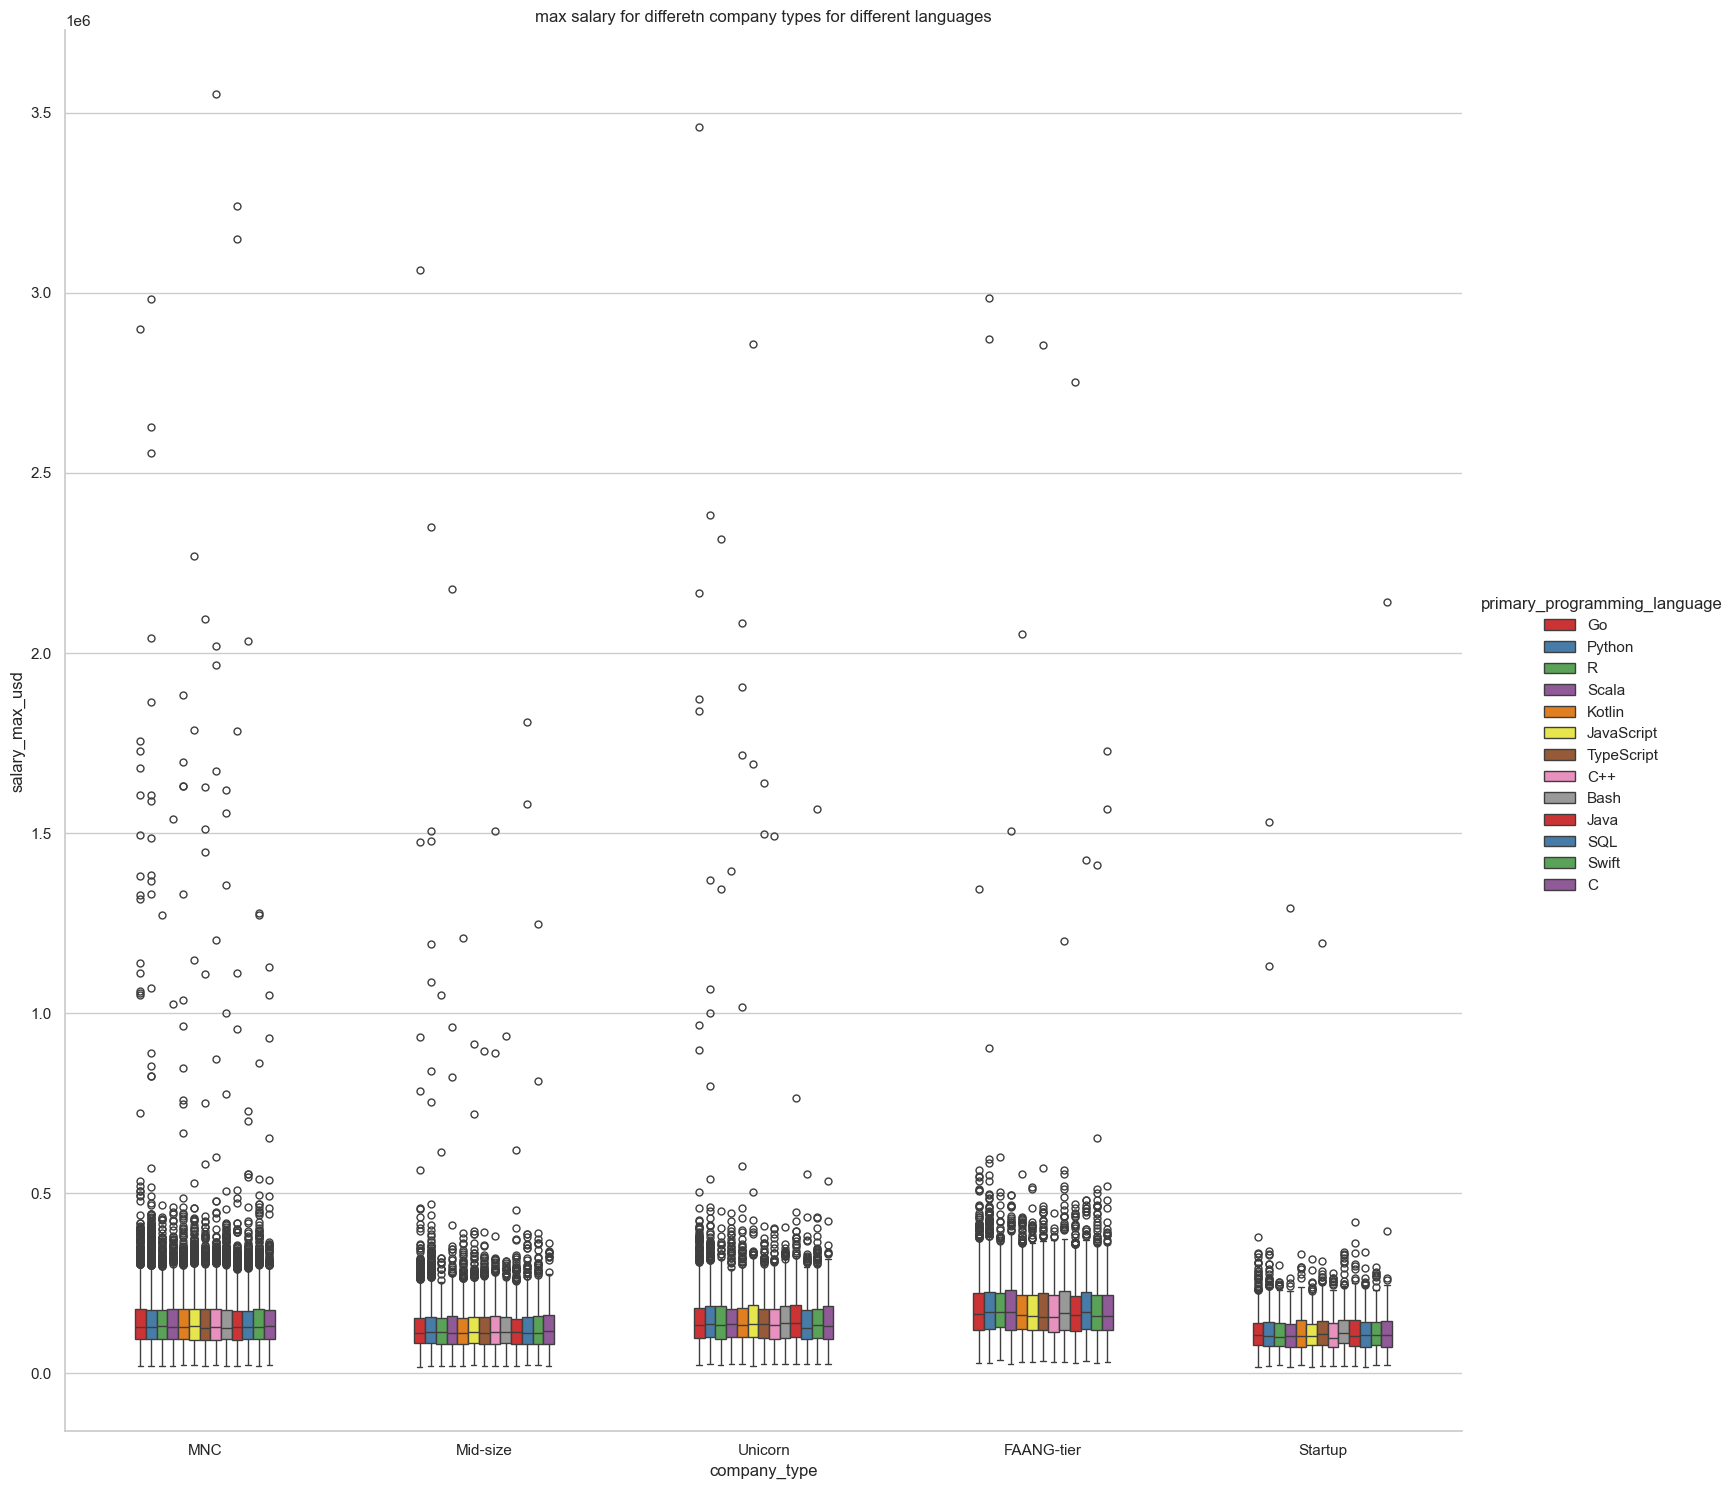

In [269]:
sns.catplot(data=df, x='company_type', y='salary_max_usd' ,hue='primary_programming_language', kind='box', dodge=True,width=0.5,height=15,aspect=1, palette='Set1')
plt.title('max salary for differetn company types for different languages')
sns.despine()
plt.show()

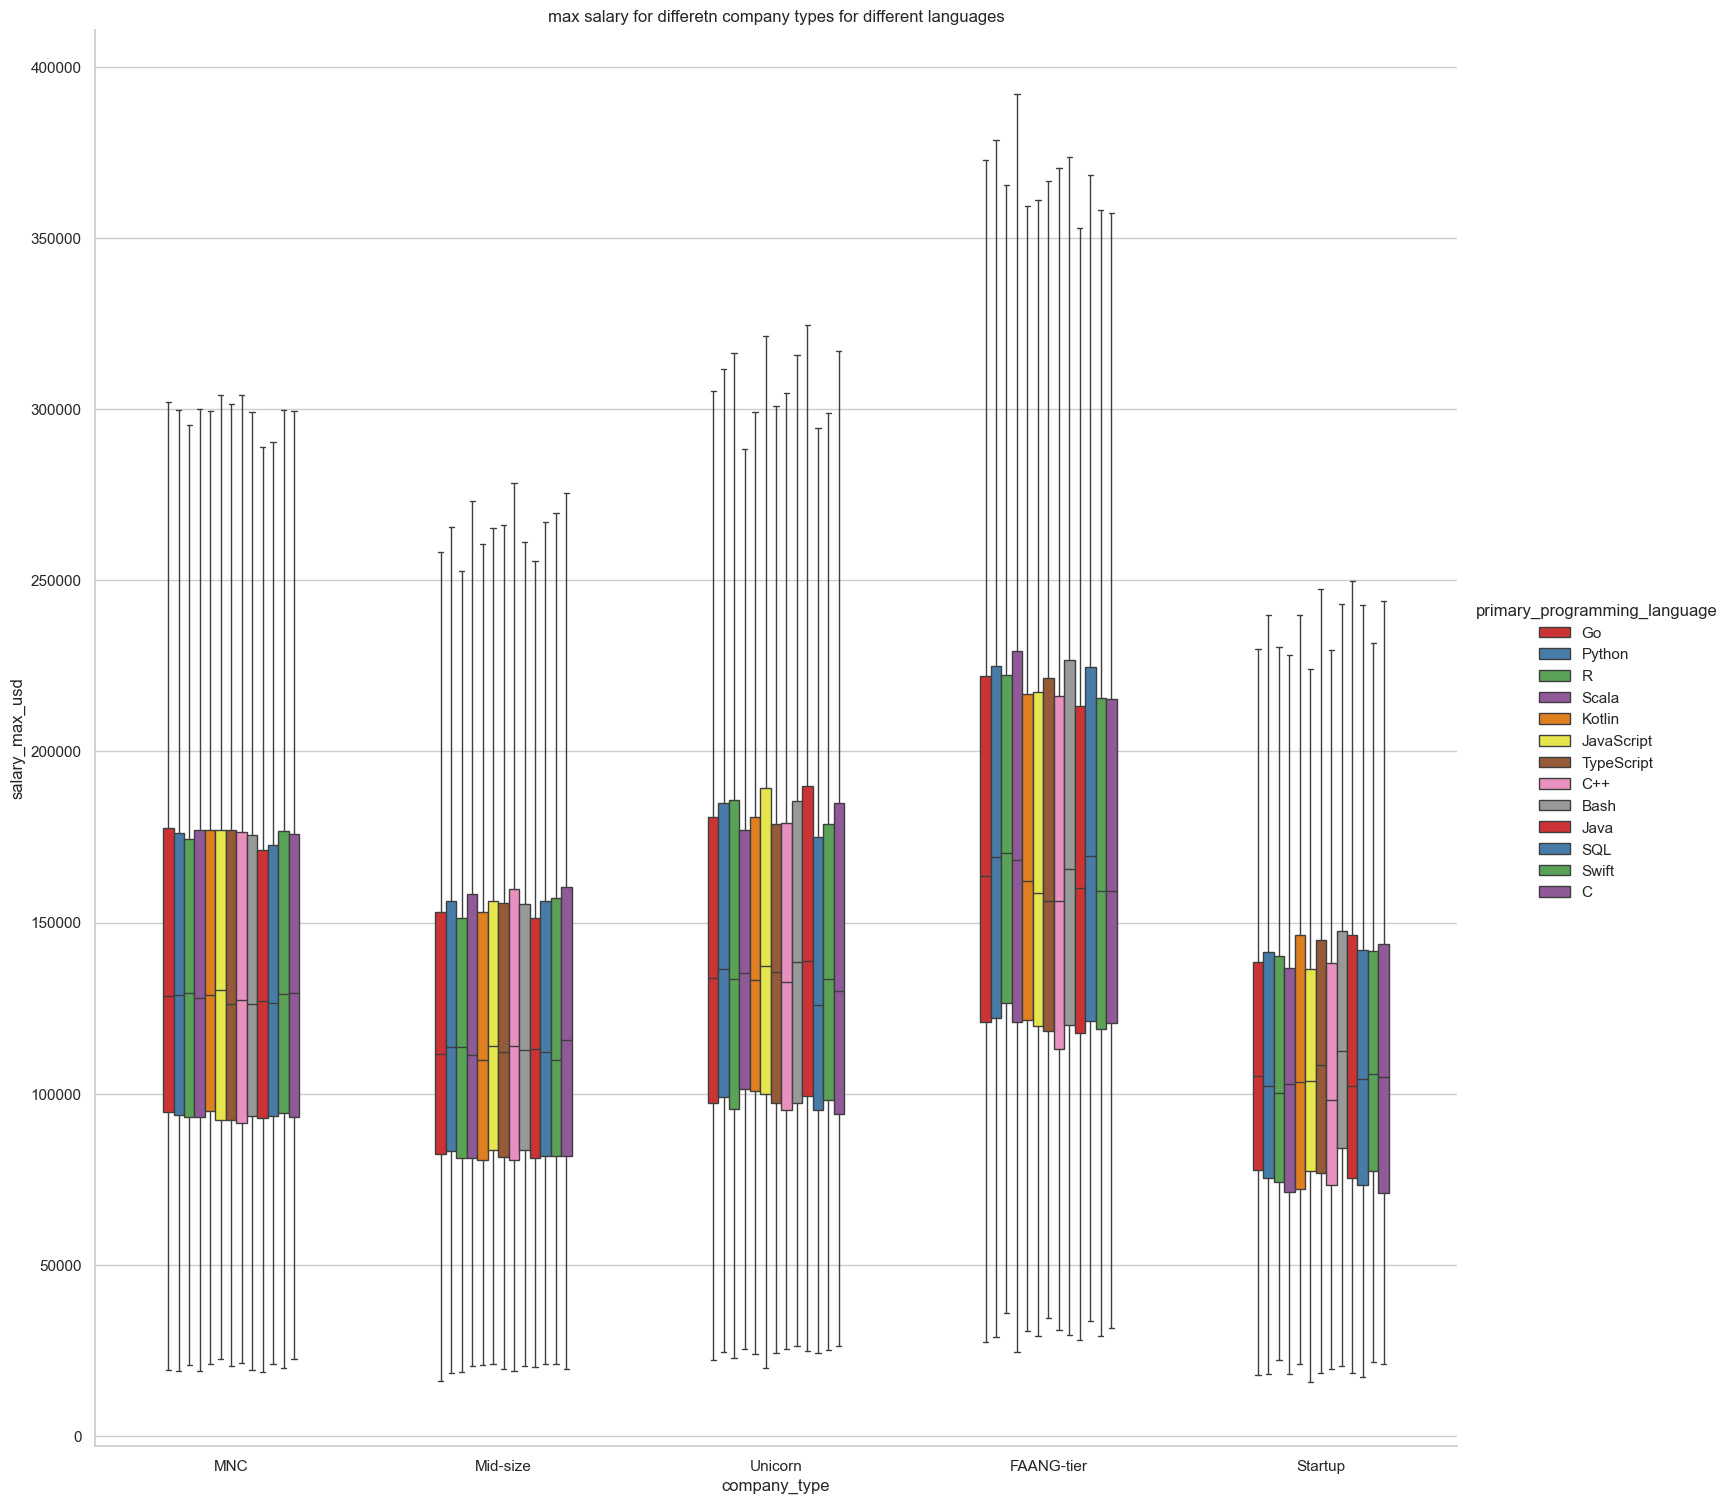

In [270]:
sns.set_theme(style="whitegrid")
sns.catplot(data=df, x='company_type', y='salary_max_usd' ,hue='primary_programming_language', kind='box',showfliers=False, dodge=True,width=0.5,height=15,aspect=1, palette='Set1')
plt.title('max salary for differetn company types for different languages')
sns.despine()
plt.show()

In [271]:
layoff=df['layoff_within_12_months_flag']

In [272]:
layoff.dtype

dtype('O')

In [273]:
layoff.isnull().value_counts()

layoff_within_12_months_flag
False    113807
Name: count, dtype: int64

In [274]:
layoff.value_counts()

layoff_within_12_months_flag
N        24905
0        24736
False    24717
No       24526
Y         3785
Yes       3759
1         3734
True      3645
Name: count, dtype: int64

In [275]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({'N':False, 'Y':True})

In [276]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({'No':False, 'Yes':True})

In [277]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({0:False, 1:True})

In [278]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({'0':False, '1':True})

In [279]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({'False':False, 'True':True})

C:\Users\DEKST\AppData\Local\Temp\ipykernel_17752\1462562364.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({'False':False, 'True':True})


In [280]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
False    98884
True     14923
Name: count, dtype: int64

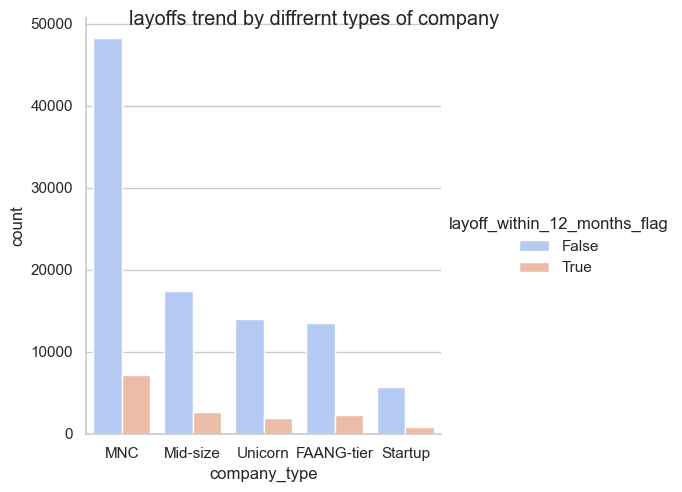

In [281]:
sns.catplot(data=df, x='company_type', hue='layoff_within_12_months_flag', kind='count' ,palette='coolwarm')
plt.suptitle('layoffs trend by diffrernt types of company')
plt.show()

In [282]:
df['posting_date'].dtype

dtype('O')

In [283]:
df['posting_date'].isnull().value_counts()

posting_date
False    113807
Name: count, dtype: int64

In [287]:
df['application_deadline'].isnull().value_counts()

application_deadline
False    108112
True       5695
Name: count, dtype: int64

In [288]:
df['application_deadline'].dtypes

dtype('O')